In [2]:
!pip install pyspark
!pip install tweepy
!pip install sparkxgb
!pip install xgboost pyspark
!pip install keyboard

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.3/212.3 MB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.6/198.6 kB 13.0 MB/s eta 0:00:00
  Created wheel for sparkxgb: filename=sparkxgb-0.1-py3-none-any.whl size=5626 sha256=5332b49537aed80d319e3496f06b8a274fa161f79fdacd6b71e68b87ec159f2b
  Stored in directory: /root/.cache/pip/wheels/b7/0c/a1/786408e13056fabeb8a72134e101b1e142fc95905c7b0e2a71
  Created wheel for pyspark: filename=pyspark-3.1.1-py2.py3-none-any.whl size=212767581 sha256=ac19ebe823b187e145c6379ea43f798ae20dc34b27255d8a359635448cbb9142
  Stored in directory: /root/.cache/pip/wheels/a0/3f/72/8efd988f9ae041f051c75e6834cd92dd6d13a726e206e8b6f3
Successfully built sparkxgb pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.7
    Uninstalling py4j-0.10.9.7:
      Successfully uninstalled py4j-0.10.9.7
  Attempting uninstall: pyspark
    Found

In [ ]:
from pyspark.sql import SparkSession, Row
from pyspark.sql.functions import when, col, lit
from pyspark.ml.feature import  VectorAssembler
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import regexp_replace
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.classification import LogisticRegression
import tweepy
from tweepy import OAuthHandler,StreamingClient,StreamResponse,streaming, OAuth2BearerHandler
import socket
import json

In [ ]:
spark= SparkSession.builder.appName("BDA Project").getOrCreate()

In [ ]:
df= spark.read.csv("/content/sample_data/Scrapped_Data_for_allinfo.csv", inferSchema=True, header=True)

In [ ]:
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- Mobile Name: string (nullable = true)
 |-- Prices: string (nullable = true)
 |-- Reviews: double (nullable = true)
 |-- RAM Specifications: integer (nullable = true)
 |-- Storage Specifications: integer (nullable = true)



In [ ]:
df=df.withColumn("Prices",(regexp_replace(col("Prices"), ",", "").cast(DoubleType())))

In [ ]:
df.dropDuplicates(["Mobile Name", "Prices", "Reviews", "RAM Specifications", "Storage Specifications"])

In [ ]:
df.head(1)

In [ ]:
df= df.na.fill(4, subset=['RAM Specifications'])

In [ ]:
df.na.drop()

In [ ]:
df.count()

In [ ]:
df= df.withColumn("Reviews", when(df["Reviews"] >5.0, df["Reviews"]-4).otherwise(df["Reviews"]))

In [ ]:
df.show()

In [ ]:
df0_10000 = df.filter((col("Prices") < 10000))

In [ ]:
df0_10000.count()

In [ ]:
df0_10000.dropDuplicates(["Mobile Name", "Prices", "Reviews", "RAM Specifications", "Storage Specifications"])

In [ ]:
df0_10000.count()

In [ ]:
df10000_40000 = df.filter((col("Prices") >= 10000) & (col("Prices") <= 400000))

In [ ]:
df10000_40000.dropDuplicates(["Mobile Name", "Prices", "Reviews", "RAM Specifications", "Storage Specifications"])

In [ ]:
df10000_40000.count()

In [ ]:
df10000_40000.printSchema()

In [ ]:
assembler= VectorAssembler(inputCols=['Prices','Reviews','RAM Specifications','Storage Specifications'], outputCol='features', handleInvalid='skip')

In [ ]:
output0_10000= assembler.transform(df0_10000)

In [ ]:
output0_10000.head()

In [ ]:
fnl_data0_10000=output0_10000.select('features','Reviews')

In [ ]:
fnl_data0_10000.show()

In [ ]:
train_fnl_data, test_fnl_data= fnl_data0_10000.randomSplit([0.7,0.3])

In [ ]:
fnl_data0_10000.na.drop()

In [ ]:
fnl_data0_10000.count()

In [ ]:
train_fnl_data.count()

In [ ]:
train_fnl_data.printSchema()

In [ ]:
rfr= RandomForestRegressor(featuresCol='features',labelCol='Reviews')

In [ ]:
rfr_model=rfr.fit(train_fnl_data)

In [ ]:
predictions= rfr_model.transform(test_fnl_data)

In [ ]:
predictions.select("prediction", "Reviews", "features").show(20)


In [ ]:
evaluator_rmse = RegressionEvaluator(labelCol="Reviews", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="Reviews", predictionCol="prediction", metricName="r2")


In [ ]:
rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)


In [ ]:
print(f"Root Mean Squared Error (RMSE) on test data = {rmse}")
print(f"R^2 on test data = {r2}")

In [ ]:
fnl_data0_10000.describe().show()

In [ ]:
correlation_prices = df0_10000.stat.corr("Prices", "Reviews")
print(f"Correlation between Reviews and Prices: {correlation_prices}")

In [ ]:
correlation_ram = df0_10000.stat.corr("RAM Specifications", "Reviews")
print(f"Correlation between Reviews and RAM Specifications: {correlation_ram}")

correlation_storage = df0_10000.stat.corr("Storage Specifications", "Reviews")
print(f"Correlation between Reviews and Storage Specifications: {correlation_storage}")

In [ ]:
def predict_review(price, ram_spec, storage_spec):
    # Create a DataFrame from the user input
    user_input = Row(Prices=price, RAM_Specifications=ram_spec, Storage_Specifications=storage_spec)
    user_df = spark.createDataFrame([user_input])

    # Preprocess the input data similarly to the training data
    user_df = user_df.withColumn("Prices", regexp_replace(col("Prices"), ",", "").cast(DoubleType()))

    # Fill missing RAM specification values if necessary (e.g., fill with 4 as in your code)
    user_df = user_df.na.fill(4, subset=["RAM_Specifications"])

    # Assemble the features (ensure that the column names match the training data)
    assembler = VectorAssembler(inputCols=['Prices', 'RAM_Specifications', 'Storage_Specifications'],
                                outputCol='features', handleInvalid='skip')
    user_df = assembler.transform(user_df)

    # Make predictions using the trained model
    prediction = rfr_model.transform(user_df)

    # Show the predicted review score
    prediction.select("prediction").show()

In [ ]:
predict_review(price=15000,ram_spec=8, storage_spec=128)

In [ ]:
logistic_columns= df.select(["Mobile Name", "Prices", "Reviews", "RAM Specifications", "Storage Specifications"])

In [ ]:
logistic_columns.printSchema()

In [ ]:
from pyspark.sql import SparkSession, Row
from pyspark.sql.functions import when, col, lit, regexp_replace, split
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline

# Create Spark session
spark = SparkSession.builder.appName("BDA Project").getOrCreate()

# Read and preprocess data
df = spark.read.csv("/content/sample_data/Scrapped_Data_for_allinfo.csv", inferSchema=True, header=True)

# Clean up data
df = df.withColumn("Prices", regexp_replace(col("Prices"), ",", "").cast(DoubleType()))
df = df.na.fill(4, subset=["RAM Specifications"])
df = df.withColumn("Reviews", when(df["Reviews"] > 5.0, df["Reviews"] - 4).otherwise(df["Reviews"]))
df = df.dropDuplicates(["Mobile Name", "Prices", "Reviews", "RAM Specifications", "Storage Specifications"])

# Handle outliers
df = df.filter((col("Prices") > 100) & (col("Prices") < 50000))
df = df.filter((col("Reviews") >= 0) & (col("Reviews") <= 10))

# Extract brand name
df = df.withColumn("Brand", split(col("Mobile Name"), " ").getItem(0))

# Add price category
df = df.withColumn(
    "Price_Category",
    when(df["Prices"] < 5000, 0)
    .when((df["Prices"] >= 5000) & (df["Prices"] < 20000), 1)
    .otherwise(2)
)

# Filter price ranges and split data
df0_10000 = df.filter(col("Prices") < 10000)
train_data, test_data = df0_10000.randomSplit([0.7, 0.3], seed=42)

# Create the pipeline stages with handleInvalid="keep"
brand_indexer = StringIndexer(
    inputCol="Brand",
    outputCol="BrandIndex",
    handleInvalid="keep"  # This is the key change
)

brand_encoder = OneHotEncoder(
    inputCol="BrandIndex",
    outputCol="BrandVec",
    handleInvalid="keep"  # Also handling invalid cases here
)

# Create feature columns list
feature_cols = ["Prices", "RAM Specifications", "Storage Specifications", "Price_Category"]

# Create the assembler
assembler = VectorAssembler(
    inputCols=feature_cols + ["BrandVec"],
    outputCol="features",
    handleInvalid="keep"  # Handle invalid features
)

# Create the random forest regressor
rfr = RandomForestRegressor(
    featuresCol="features",
    labelCol="Reviews",
    numTrees=100,
    maxDepth=10
)

# Create the pipeline
pipeline = Pipeline(stages=[
    brand_indexer,
    brand_encoder,
    assembler,
    rfr
])

# Create parameter grid
param_grid = ParamGridBuilder() \
    .addGrid(rfr.numTrees, [50, 100]) \
    .addGrid(rfr.maxDepth, [5, 10]) \
    .build()

# Create evaluator
evaluator = RegressionEvaluator(
    labelCol="Reviews",
    predictionCol="prediction",
    metricName="rmse"
)

# Create cross validator with fewer folds to reduce computation time
crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    numFolds=2,  # Reduced from 3 to 2 for faster computation
    parallelism=2  # Add parallel processing
)

# Fit the model
print("Training model...")
cv_model = crossval.fit(train_data)

# Make predictions
print("Making predictions...")
predictions = cv_model.transform(test_data)

# Evaluate the model
rmse = evaluator.evaluate(predictions)
r2 = RegressionEvaluator(
    labelCol="Reviews",
    predictionCol="prediction",
    metricName="r2"
).evaluate(predictions)

print(f"Root Mean Squared Error (RMSE) on test data = {rmse}")
print(f"R^2 on test data = {r2}")

# Show feature importance
if hasattr(cv_model.bestModel.stages[-1], 'featureImportances'):
    feature_importance = cv_model.bestModel.stages[-1].featureImportances
    print("\nFeature Importances:")
    for i, importance in enumerate(feature_importance):
        print(f"Feature {i}: {importance}")

# Function to make predictions
def predict_review(price, ram_spec, storage_spec, brand, pipeline_model):
    # Create a single row DataFrame with the input
    input_data = spark.createDataFrame([(
        "Sample Phone",  # Mobile Name
        price,          # Prices
        0.0,           # Reviews (will be predicted)
        ram_spec,       # RAM Specifications
        storage_spec,   # Storage Specifications
        brand,          # Brand
        1 if price >= 5000 and price < 20000 else (0 if price < 5000 else 2)  # Price_Category
    )], ["Mobile Name", "Prices", "Reviews", "RAM Specifications",
         "Storage Specifications", "Brand", "Price_Category"])

    # Make prediction
    try:
        prediction = pipeline_model.transform(input_data)
        return prediction.select("prediction").collect()[0][0]
    except Exception as e:
        print(f"Error making prediction: {str(e)}")
        return None

# Example usage
print("\nMaking sample prediction...")
sample_prediction = predict_review(
    price=15000,
    ram_spec=6,
    storage_spec=128,
    brand="Samsung",
    pipeline_model=cv_model.bestModel
)
if sample_prediction is not None:
    print(f"Predicted review score: {sample_prediction:.2f}")

Training model...


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/pool.py", line 856, in next
    item = self._items.popleft()
IndexError: pop from an empty deque

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-1-35bd9b69211d>", line 104, in <cell line: 104>
    cv_model = crossval.fit(train_data)
  File "/usr/local/lib/python3.10/dist-packages/pyspark/ml/base.py", line 205, in fit
    return self._fit(dataset)
  File "/usr/local/lib/python3.10/dist-packages/pyspark/ml/tuning.py", line 847, in _fit
    for j, metric, subModel in pool.imap_unordered(lambda f: f(), tasks):
  File "/usr/lib/python3.10/multiprocessing/pool.py", line 861, in next
    self._cond.wait(timeout)
  File "/usr/lib/python3.10/threading.py", line 320, in wait
    wai

TypeError: object of type 'NoneType' has no len()

In [ ]:
sample_prediction = predict_review(
    price=91000,
    ram_spec=8,
    storage_spec=128,
    brand="Xiomi",
    pipeline_model=cv_model.bestModel
)
if sample_prediction is not None:
    print(f"Predicted review score: {sample_prediction:.2f}")

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col, regexp_replace, split
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml import Pipeline
import xgboost as xgb
import pandas as pd
import numpy as np

# Create Spark session
spark = SparkSession.builder.appName("BDA Project").getOrCreate()

# Read and preprocess data
df = spark.read.csv("/content/sample_data/Scrapped_Data_for_allinfo.csv", inferSchema=True, header=True)

# Clean up data
df = df.withColumn("Prices", regexp_replace(col("Prices"), ",", "").cast("double"))
df = df.na.fill(4, subset=["RAM Specifications"])
df = df.withColumn("Reviews", when(df["Reviews"] > 5.0, df["Reviews"] - 4).otherwise(df["Reviews"]))
df = df.dropDuplicates(["Mobile Name", "Prices", "Reviews", "RAM Specifications", "Storage Specifications"])

# Handle outliers
df = df.filter((col("Prices") > 100) & (col("Prices") < 50000))
df = df.filter((col("Reviews") >= 0) & (col("Reviews") <= 10))

# Extract brand name
df = df.withColumn("Brand", split(col("Mobile Name"), " ").getItem(0))

# Add price category
df = df.withColumn(
    "Price_Category",
    when(df["Prices"] < 5000, 0)
    .when((df["Prices"] >= 5000) & (df["Prices"] < 20000), 1)
    .otherwise(2)
)

# Filter price ranges and split data
df0_10000 = df.filter(col("Prices") < 10000)
train_data, test_data = df0_10000.randomSplit([0.7, 0.3], seed=42)

# Create the pipeline stages
brand_indexer = StringIndexer(
    inputCol="Brand",
    outputCol="BrandIndex",
    handleInvalid="skip"  # This will skip invalid labels in StringIndexer
)

brand_encoder = OneHotEncoder(
    inputCol="BrandIndex",
    outputCol="BrandVec",
    dropLast=True  # Drop the last category to avoid issues with one-hot encoding
)

# Create feature columns list
feature_cols = ["Prices", "RAM Specifications", "Storage Specifications", "Price_Category"]

# Create the assembler
assembler = VectorAssembler(
    inputCols=feature_cols + ["BrandVec"],
    outputCol="features",
    handleInvalid="skip"  # Handle invalid features during assembly
)

# Create the pipeline
pipeline = Pipeline(stages=[
    brand_indexer,
    brand_encoder,
    assembler
])

# Fit the pipeline to the training data
model = pipeline.fit(train_data)

# Transform the train and test data
train_transformed = model.transform(train_data)
test_transformed = model.transform(test_data)

# Convert to Pandas for XGBoost
train_pd = train_transformed.select("features", "Reviews").toPandas()
test_pd = test_transformed.select("features", "Reviews").toPandas()

# XGBoost expects a numpy array format
X_train = np.array([x.toArray() for x in train_pd["features"]])
y_train = train_pd["Reviews"].values
X_test = np.array([x.toArray() for x in test_pd["features"]])
y_test = test_pd["Reviews"].values

# Create DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define parameters for XGBoost
params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'eta': 0.1,
    'eval_metric': 'rmse'
}

# Train the model
xgb_model = xgb.train(params, dtrain, num_boost_round=100)

# Make predictions
predictions = xgb_model.predict(dtest)

# Evaluate the model
rmse = np.sqrt(((predictions - y_test) ** 2).mean())
print(f"Root Mean Squared Error (RMSE) on test data = {rmse}")

# Example prediction function
def predict_review(price, ram_spec, storage_spec, brand, model):
    # Create a single row DataFrame with the input
    input_data = spark.createDataFrame([(
        "Sample Phone",  # Mobile Name
        price,           # Prices
        0.0,             # Reviews (will be predicted)
        ram_spec,        # RAM Specifications
        storage_spec,    # Storage Specifications
        brand,           # Brand
        1 if price >= 5000 and price < 20000 else (0 if price < 5000 else 2)  # Price_Category
    )], ["Mobile Name", "Prices", "Reviews", "RAM Specifications",
         "Storage Specifications", "Brand", "Price_Category"])

    # Transform the input data using the same pipeline
    transformed_input = model.transform(input_data)

    # Convert to Pandas for prediction
    input_pd = transformed_input.select("features").toPandas()
    X_input = np.array([x.toArray() for x in input_pd["features"]])

    # Make prediction with XGBoost
    prediction = xgb_model.predict(xgb.DMatrix(X_input))
    return prediction[0]



Root Mean Squared Error (RMSE) on test data = 0.9976216003213545


In [ ]:
print("\nMaking sample prediction...")
sample_prediction = predict_review(
    price=25000,
    ram_spec=16,
    storage_spec=128,
    brand="SAMSUNG",
    model=model
)
print(f"Predicted review score: {sample_prediction:.2f}")



Making sample prediction...
Predicted review score: 3.33


In [3]:
import socket
import tweepy
import json
import time
import keyboard
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, TimestampType


consumer_key = 'SvKhuf7ZFEFgEFx1R5SUVQn5r'
consumer_secret = 'beQXKhQAgYQWlaZrd3pGrvp9JdX4H9RqFfy8U8uJNAmAWTBzez'
access_token = '1774429511393882112-crl3vLbYurQUTy4Qsv2yjjoPu8jg9x'
access_secret = 'YgWUaXGDmahZV8uoIRenZVnzAw3MzKLbpXuiqgCTLrFf0'
BEARER_TOKEN = 'AAAAAAAAAAAAAAAAAAAAAOpwwwEAAAAABvUinglAFPJ5889RnnyDa9m9PCU%3DLeswCkysTDRXvRpMPo7uIBgjFrUARPnXNejXTi1bLg0JwIpQAj'


auth = tweepy.OAuthHandler(consumer_key, consumer_secret)
auth.set_access_token(access_token, access_secret)
api = tweepy.API(auth)

spark = SparkSession.builder.master("local").appName("CompanyTweets").getOrCreate()

def get_tweets(keywords, tweet_limit=100):
    client = tweepy.Client(bearer_token=BEARER_TOKEN)

    tweet_list = []

    # Define schema explicitly
    schema = StructType([
        StructField("tweet", StringType(), True),
        StructField("created_at", TimestampType(), True),
        StructField("company", StringType(), True)
    ])

    while True:
        if keyboard.is_pressed('n'):
            print("Exiting the program...")
            break

        try:
            for keyword in keywords:
                response = client.search_recent_tweets(query=keyword, max_results=100)
                if response.data:
                    for tweet in response.data:
                        tweet_list.append({
                            'tweet': tweet.text,
                            'created_at': tweet.created_at,
                            'company': keyword
                        })

                tweet_list = tweet_list[-tweet_limit:]

                print(f"\nFetching tweets for companies: {keywords}")
                for tweet in tweet_list:
                    print(f"- {tweet['tweet']}")

                # Create DataFrame with explicit schema
                tweet_df = spark.createDataFrame(tweet_list, schema=schema)
                tweet_df.show()

                tweet_df = tweet_df.withColumn('date', F.to_date(tweet_df['created_at']))
                company_count = tweet_df.groupBy('company', 'date').count().orderBy('date')

                company_count_pd = company_count.toPandas()

                plt.figure(figsize=(10, 6))
                for company in keywords:
                    company_data = company_count_pd[company_count_pd['company'] == company]
                    plt.plot(company_data['date'], company_data['count'], label=company)

                plt.xlabel('Date')
                plt.ylabel('Number of Tweets')
                plt.title('Number of Tweets per Company Over Time')
                plt.legend()
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()

            else:
                print("No tweets found for this keyword.")

        except tweepy.errors.TooManyRequests as e:
            print("Rate limit reached. Sleeping for 15 minutes...")
            time.sleep(900)
        time.sleep(5)

if __name__ == '__main__':
    companies = ['Tesla', 'Google', 'Apple', 'Microsoft']
    get_tweets(companies, tweet_limit=100)


/usr/local/lib/python3.10/dist-packages/keyboard/_nixkeyboard.py:110: UserWarning: Failed to create a device file using `uinput` module. Sending of events may be limited or unavailable depending on plugged-in devices.
  device = aggregate_devices('kbd')
Exception in thread Thread-11 (start_reading):
Traceback (most recent call last):
  File "/usr/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
Exception in thread     self.run()
  File "/usr/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.10/dist-packages/keyboard/_nixcommon.py", line 106, in start_reading
    self.event_queue.put(device.read_event())
  File "/usr/local/lib/python3.10/dist-packages/keyboard/_nixcommon.py", line 83, in read_event
    data = self.input_file.read(struct.calcsize(event_bin_format))
AttributeError: 'NoneType' object has no attribute 'read'
Thread-12 (start_reading):
Traceback (most recent call last):
  File "/usr/lib/pyt

FileNotFoundError: [Errno 2] No such file or directory: 'dumpkeys'

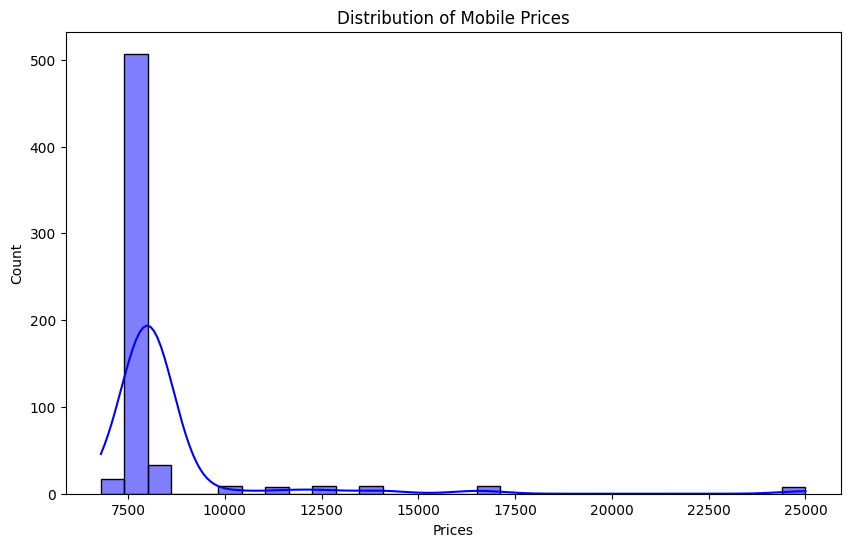

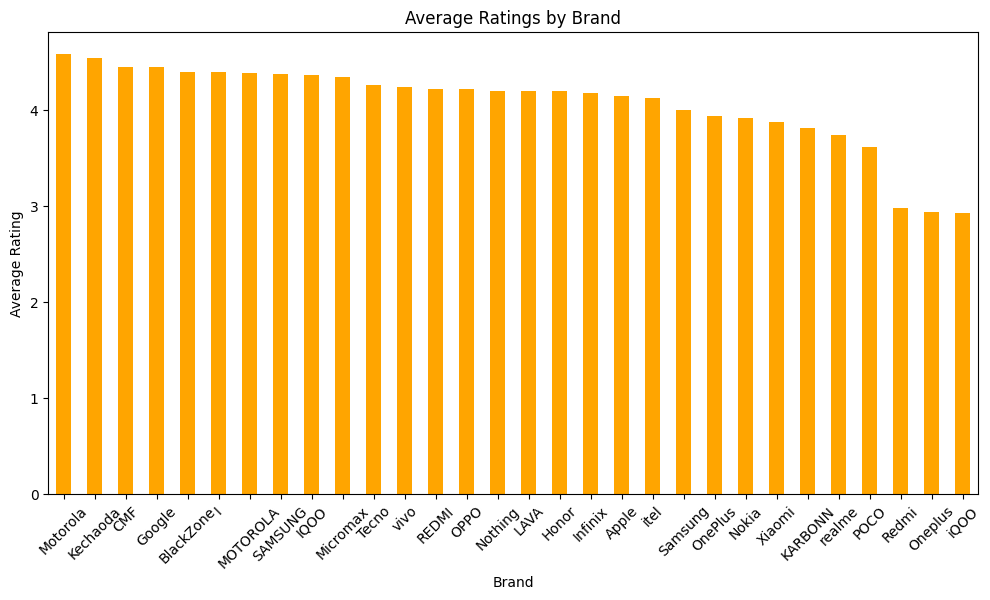

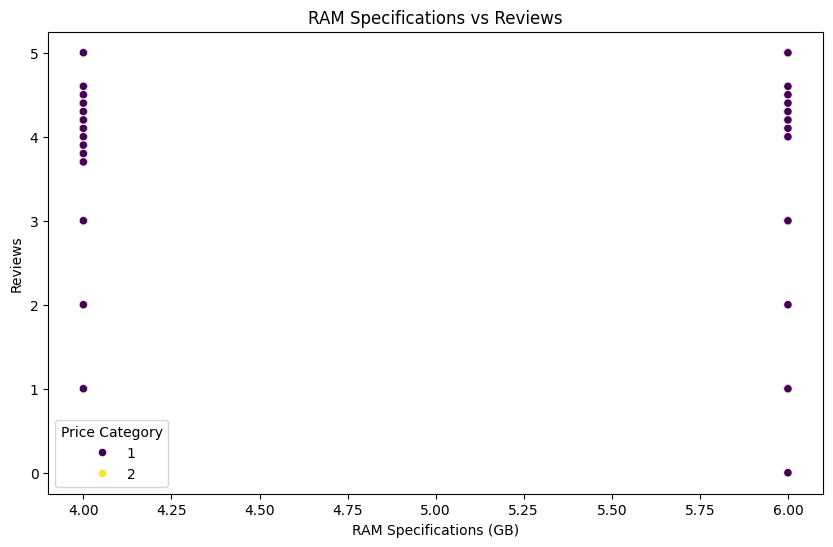

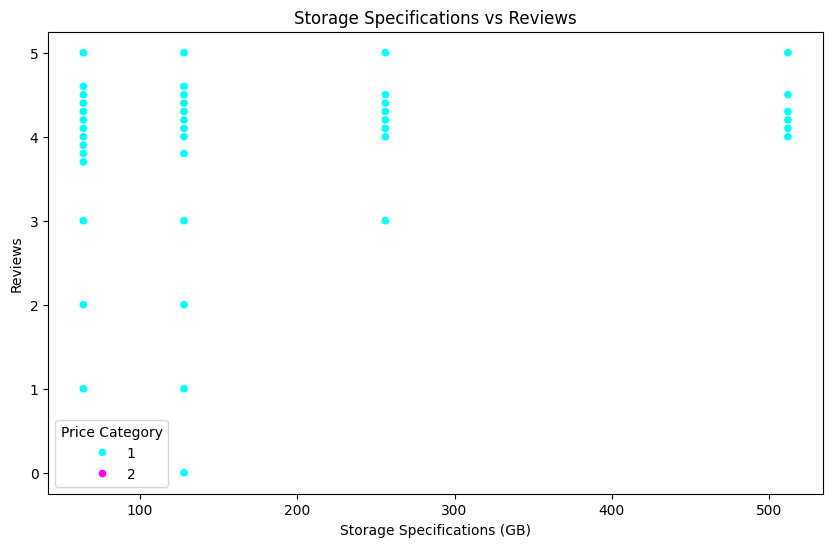

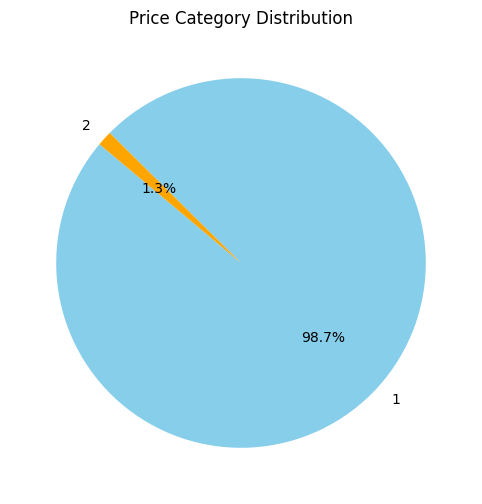

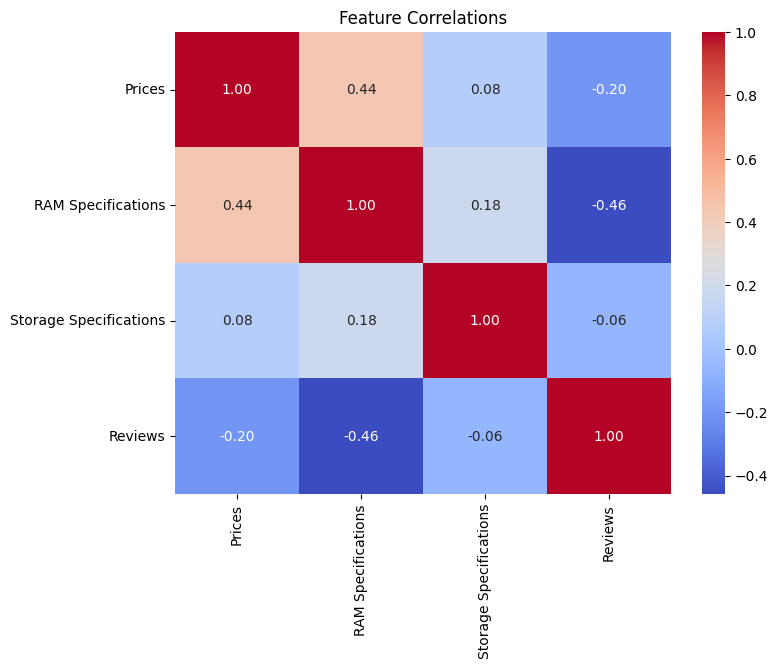

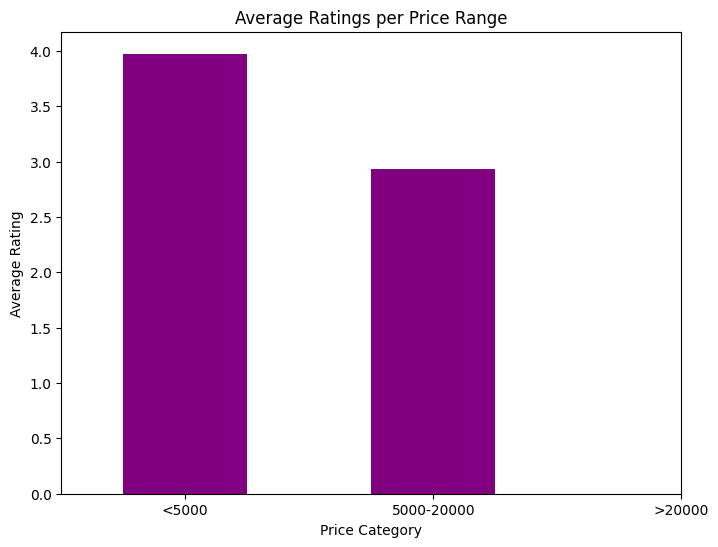

<ipython-input-8-78fc4f38370e>:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pd, x="Brand", y="Prices", palette="Set3")


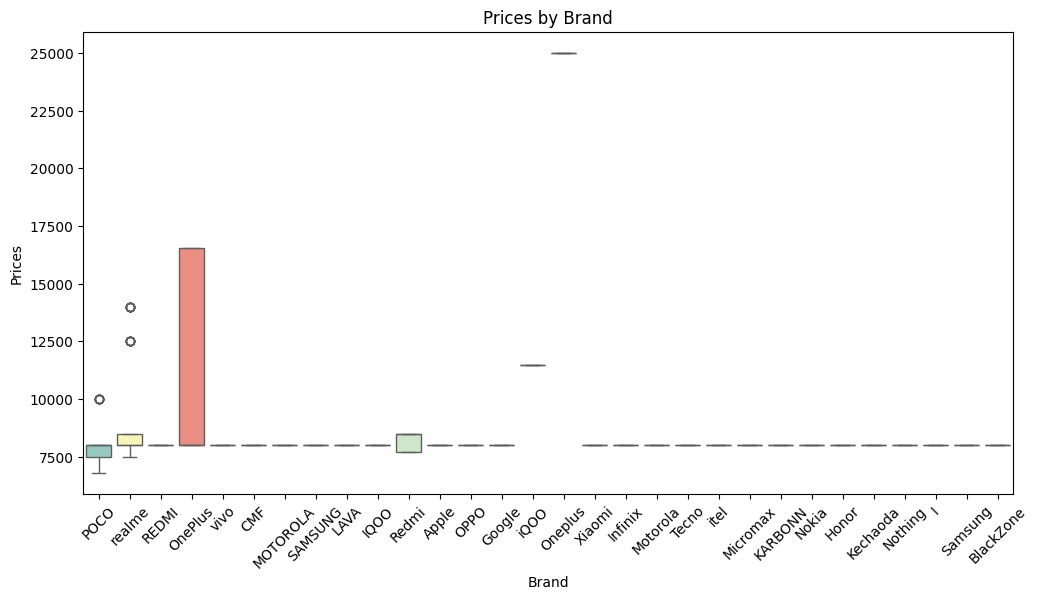

<ipython-input-8-78fc4f38370e>:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pd, x="Price_Category", y="Reviews", palette="pastel")


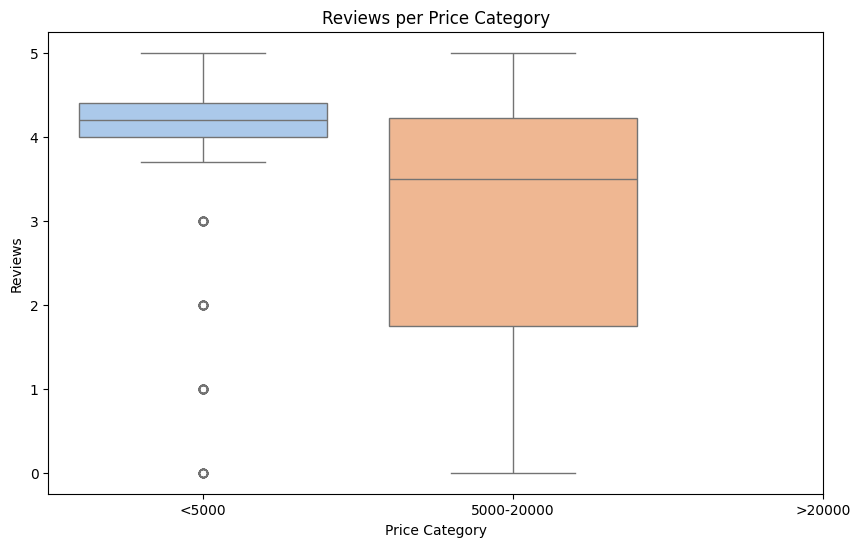

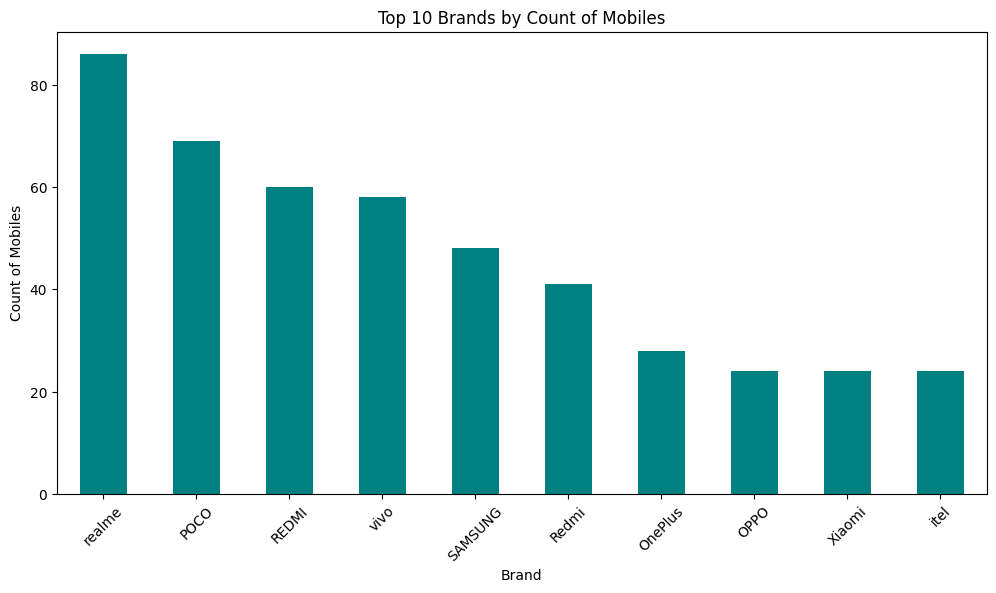

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the full dataframe to Pandas for visualization
df_pd = df.toPandas()

# 1. Distribution of Prices
plt.figure(figsize=(10, 6))
sns.histplot(df_pd["Prices"], bins=30, kde=True, color="blue")
plt.title("Distribution of Mobile Prices")
plt.xlabel("Prices")
plt.ylabel("Count")
plt.show()

# 2. Average Ratings by Brand
avg_ratings_by_brand = df_pd.groupby("Brand")["Reviews"].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
avg_ratings_by_brand.plot(kind='bar', color="orange")
plt.title("Average Ratings by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

# 3. RAM vs. Reviews
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pd, x="RAM Specifications", y="Reviews", hue="Price_Category", palette="viridis")
plt.title("RAM Specifications vs Reviews")
plt.xlabel("RAM Specifications (GB)")
plt.ylabel("Reviews")
plt.legend(title="Price Category")
plt.show()

# 4. Storage vs. Reviews
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pd, x="Storage Specifications", y="Reviews", hue="Price_Category", palette="cool")
plt.title("Storage Specifications vs Reviews")
plt.xlabel("Storage Specifications (GB)")
plt.ylabel("Reviews")
plt.legend(title="Price Category")
plt.show()

# 5. Price Category Distribution
plt.figure(figsize=(8, 6))
df_pd["Price_Category"].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=["skyblue", "orange", "green"])
plt.title("Price Category Distribution")
plt.ylabel("")
plt.show()

# 6. Heatmap of Feature Correlations
numeric_cols = ["Prices", "RAM Specifications", "Storage Specifications", "Reviews"]
correlation_matrix = df_pd[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlations")
plt.show()

# 7. Average Ratings per Price Range
avg_ratings_by_category = df_pd.groupby("Price_Category")["Reviews"].mean()
plt.figure(figsize=(8, 6))
avg_ratings_by_category.plot(kind='bar', color="purple")
plt.title("Average Ratings per Price Range")
plt.xlabel("Price Category")
plt.ylabel("Average Rating")
plt.xticks([0, 1, 2], ['<5000', '5000-20000', '>20000'], rotation=0)
plt.show()

# 8. Box Plot for Prices by Brand
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_pd, x="Brand", y="Prices", palette="Set3")
plt.title("Prices by Brand")
plt.xlabel("Brand")
plt.ylabel("Prices")
plt.xticks(rotation=45)
plt.show()

# 9. Reviews per Price Category
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_pd, x="Price_Category", y="Reviews", palette="pastel")
plt.title("Reviews per Price Category")
plt.xlabel("Price Category")
plt.ylabel("Reviews")
plt.xticks([0, 1, 2], ['<5000', '5000-20000', '>20000'], rotation=0)
plt.show()

top_brands = df_pd["Brand"].value_counts().head(10)
plt.figure(figsize=(12, 6))
top_brands.plot(kind='bar', color="teal")
plt.title("Top 10 Brands by Count of Mobiles")
plt.xlabel("Brand")
plt.ylabel("Count of Mobiles")
plt.xticks(rotation=45)
plt.show()

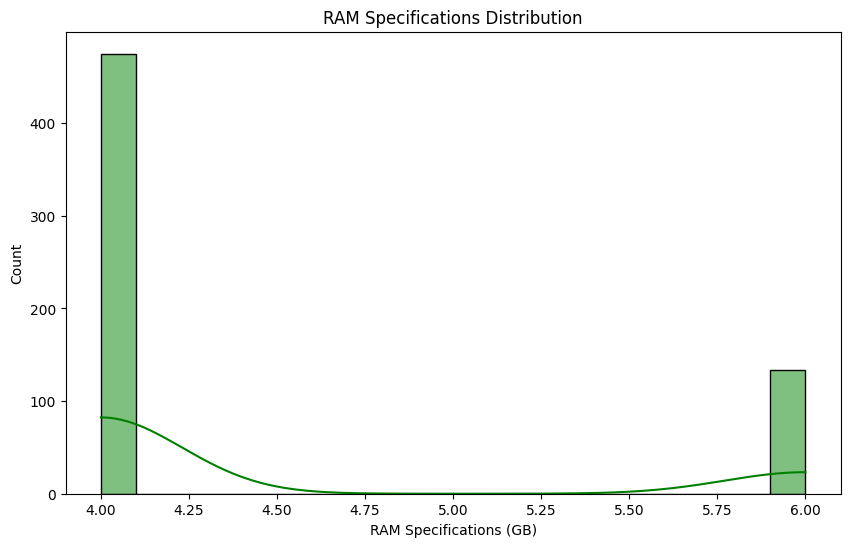

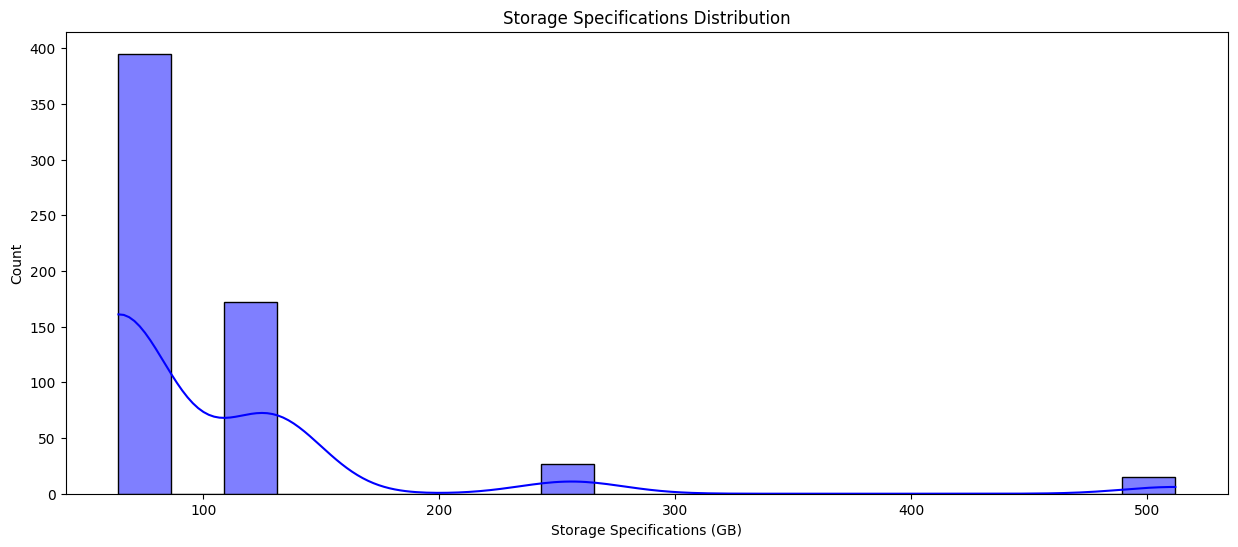

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df_pd["RAM Specifications"], bins=20, kde=True, color="green")
plt.title("RAM Specifications Distribution")
plt.xlabel("RAM Specifications (GB)")
plt.ylabel("Count")
plt.show()

# 8. Storage Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_pd["Storage Specifications"], bins=20, kde=True, color="blue")
plt.title("Storage Specifications Distribution")
plt.xlabel("Storage Specifications (GB)")
plt.ylabel("Count")
plt.show()